# Cross-layer EDA 01: Coverage and Join Audit

## 1. The biological question

Every single-layer notebook (`eda/single_layer/01`-`17`) reported its own coverage percentage
against its **own file's row count** — HPA against its 1,206 cell lines, proteomics against its
375, CRISPR against its 1,208. Those numbers are correct in isolation and useless together: a
researcher who includes five genes and gets evidence from three layers needs to know what fraction
of **one shared, gated population** each layer actually reaches, not five different denominators
that were never the same population to begin with.

`docs/PROJECT_ARCHITECTURE.md` §7 states the rule this notebook exists to make possible:

> Score over the layers actually measured, renormalising the layer weights over exactly those
> layers... **Never multiply coverage into the score.**

Renormalising "over exactly those layers" requires knowing, for every candidate cell line, exactly
which layers are `measured`, `measured_absent`, or `not_assayed` (§7's three states) — and knowing
that against **one identity spine**, not seventeen different ones. Without a single spine:

- a coverage percentage cannot be compared across layers (different denominators secretly mean
  different populations);
- a per-gene, per-layer desirability mean (§5b) has no reliable "layers with evidence" set to
  average over;
- the missing-evidence framing in §7 ("fusion status unknown", never "no fusion") cannot be applied
  consistently, because "unknown" is only a meaningful statement relative to a population that was
  eligible to be measured in the first place.

This notebook builds that one spine, gates it to human cancer cell lines, and joins all eleven
measurement layers to it. Every coverage number from here on is a percentage of the **same**
population — the number every later notebook (02 lineage bias, 03 RNA concordance, and eventually
`docs/PROJECT_ARCHITECTURE.md` §6's admission-gate table) must cite instead of recomputing its own.

**Interpretation rule carried from `docs/PROJECT_ARCHITECTURE.md` §7:** a layer's absence for a
line is missing evidence, not a biological zero, and coverage figures below are never a judgement
about biology — only about which assay ran on which line.

## 2. Source, release, and table grain

Two identity/bridge groups and eleven measurement layers, all from `data/raw/` and
`data/augmented/` only (never `data/depmap_24Q4/` or `data/external/` — out of scope here per the
brief for this notebook).

**Identity and bridge tables**

| # | File | Grain | Role |
|---|---|---|---|
| 7 | `7_cellosaurus.csv` | one row per registered cell line (~152k, all species) | universal identity bridge; human/cancer gate |
| 8 | `8_DepMap_OmicsProfiles.csv` | one row per sequencing run (`ProfileID`) | `ProfileID` -> `ModelID` bridge, filter by `Datatype` |
| 9 | `9_DepMap_sample_info.csv` | one row per cell line, legacy schema | identity hub, `DepMap_ID` |
| 10 | `10_GEOInfo.txt` | one row per GEO sample | GEO -> Cellosaurus bridge |
| 11 | `11_hpa_rna_celline_description.tsv` | one row per HPA cell line name | HPA -> Cellosaurus bridge |
| 17 | `17_Model.csv` (augmented) | one row per cell line, modern schema | identity hub, `ModelID`, resolves legacy orphans |

**Measurement layers audited in this notebook**

| Layer | File | Native key | Filter needed before joining |
|---|---|---|---|
| HPA RNA | 1 | free-text `Cell line` name | 3-hop bridge: file 1 -> 11 -> 7 -> spine |
| DepMap RNA | 2 | `ProfileID` | file 8, `Datatype == 'rna'` |
| GEO RNA | 3 | `GSM...` column | 3-hop bridge: file 3 -> 10 -> 7 -> spine |
| Proteomics | 4 | `ModelID` (row index) | none — direct 1:1 |
| Fusions | 5 | `ModelID` | `IsDefaultEntryForModel == 'Yes'` |
| Mutations | 6 | `ProfileID` | file 8, `Datatype in {'wes','wgs'}` |
| Metabolomics | 12 | `DepMap_ID` (fallback `CCLE_ID`) | none — direct, with a name fallback for ~1 row |
| miRNA | 13 | `CCLE_ID` (GCT column) | `skiprows=2`, map `Description` before transposing |
| Genome signatures | 14 | `ModelID` | `IsDefaultEntryForModel == 'Yes'` |
| CRISPR dependency | 15 (augmented) | `ModelID` (row index) | none — direct 1:1 |
| Copy number (WGS) | 16 (augmented) | `ModelID` | `IsDefaultEntryForModel == 'Yes'` |

Every filter above was established by its own single-layer notebook (cited per row in the sections
below) — this notebook reuses that logic rather than re-deriving it, then applies the one
correction those notebooks could not make on their own: reporting coverage against a shared
denominator.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'raw' / 'gene_expression').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the az-team25 repo (data/raw/ not found).')


ROOT = find_project_root(Path.cwd())
RAW = ROOT / 'data' / 'raw'
GENE_EXPRESSION = RAW / 'gene_expression'
GENE_PROPERTIES = RAW / 'gene_properties'
NOMENCLATURE = RAW / 'nomenclature'
NON_GENE_EXPRESSION = RAW / 'non_gene_expression'
AUGMENTED = ROOT / 'data' / 'augmented'
print(f"Project root: {ROOT}")

Project root: D:\uob\final\az-team25


## 3. Build the primary identity spine

`docs/PROJECT_ARCHITECTURE.md` §2 names the core problem directly: AZ's delivery is not
release-coherent. File 9 carries the **legacy** DepMap schema (`DepMap_ID`), while files 5, 8, 15,
16, 17 carry the **modern** schema (`ModelID`). Both identifiers live in the same `ACH-xxxxxx`
string space, so the spine is simply their union — but that union has to be computed, not assumed.

`eda/single_layer/17_model_master_id_resolution_eda.ipynb` §2 already measured this reconciliation
once (1,840 legacy / 2,154 modern / 1,820 overlap / 334 orphans-in-17 / 20 orphans-in-9). The first
job here is reproducing those five numbers independently, as a check that notebook 17 is
reproducible before anything is built on top of it.

In [2]:
df9 = pd.read_csv(NOMENCLATURE / '9_DepMap_sample_info.csv')
df17 = pd.read_csv(AUGMENTED / 'nomenclature' / '17_Model.csv')

legacy_ids = set(df9['DepMap_ID'].dropna())
modern_ids = set(df17['ModelID'].dropna())
overlap_ids = legacy_ids & modern_ids
orphans_in_17 = modern_ids - legacy_ids
orphans_in_9 = legacy_ids - modern_ids

print(f"Legacy DepMap_IDs (file 9)                        : {len(legacy_ids)}")
print(f"Modern ModelIDs (file 17)                         : {len(modern_ids)}")
print(f"In both (overlap)                                 : {len(overlap_ids)}")
print(f"In file 17 but NOT file 9 (orphans resolved)      : {len(orphans_in_17)}")
print(f"In file 9 but NOT file 17                         : {len(orphans_in_9)}")

reproduced = (len(legacy_ids), len(modern_ids), len(overlap_ids), len(orphans_in_17), len(orphans_in_9))
expected = (1840, 2154, 1820, 334, 20)
print(f"\nMatches notebook 17's checkpoint numbers {expected}: {reproduced == expected}")

Legacy DepMap_IDs (file 9)                        : 1840
Modern ModelIDs (file 17)                         : 2154
In both (overlap)                                 : 1820
In file 17 but NOT file 9 (orphans resolved)      : 334
In file 9 but NOT file 17                         : 20

Matches notebook 17's checkpoint numbers (1840, 2154, 1820, 334, 20): True


### Why this EDA check matters

If this cell's five numbers do not match notebook 17's, either the underlying files changed since
that notebook ran or the reconciliation logic itself was not reproducible — either way, nothing
downstream can be trusted until that is resolved. A match confirms both files are stable and the
union logic is correct, and gives the starting point for the spine: **before any gate, the union of
legacy and modern identifiers is 1,840 + 2,154 − 1,820 = 2,174 candidate cell lines.**

In [3]:
spine_ids = sorted(legacy_ids | modern_ids)
print(f"Union spine size (before any species/cancer gate): {len(spine_ids)}")

spine = pd.DataFrame({'model_id': spine_ids})
spine = spine.merge(
    df9[['DepMap_ID', 'RRID', 'lineage', 'primary_disease', 'CCLE_Name']],
    left_on='model_id', right_on='DepMap_ID', how='left',
).drop(columns=['DepMap_ID']).rename(
    columns={'RRID': 'RRID_legacy', 'lineage': 'lineage_legacy', 'primary_disease': 'disease_legacy'}
)
spine = spine.merge(
    df17[['ModelID', 'RRID', 'OncotreeLineage', 'OncotreePrimaryDisease', 'CCLEName']],
    left_on='model_id', right_on='ModelID', how='left',
).drop(columns=['ModelID']).rename(
    columns={'RRID': 'RRID_modern', 'OncotreeLineage': 'lineage_modern', 'OncotreePrimaryDisease': 'disease_modern'}
)

spine['in_legacy'] = spine['model_id'].isin(legacy_ids)
spine['in_modern'] = spine['model_id'].isin(modern_ids)

assert spine['model_id'].is_unique, "model_id must be a clean primary key for the spine"
print(f"Spine shape: {spine.shape}")
spine.head(3)

Union spine size (before any species/cancer gate): 2174


Spine shape: (2174, 11)


,model_id,RRID_legacy,lineage_legacy,disease_legacy,CCLE_Name,RRID_modern,lineage_modern,disease_modern,CCLEName,in_legacy,in_modern
0,ACH-000001,CVCL_0465,ovary,Ovarian Cancer,NIHOVCAR3_OVARY,CVCL_0465,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,NIHOVCAR3_OVARY,True,True
1,ACH-000002,CVCL_0002,blood,Leukemia,HL60_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,CVCL_0002,Myeloid,Acute Myeloid Leukemia,HL60_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,True,True
2,ACH-000003,CVCL_0025,colorectal,Colon/Colorectal Cancer,CACO2_LARGE_INTESTINE,CVCL_0025,Bowel,Colorectal Adenocarcinoma,CACO2_LARGE_INTESTINE,True,True


### Why this EDA check matters

`model_id` being unique confirms the spine is a genuine one-row-per-cell-line table before any
measurement layer is joined to it — exactly the identity/coverage table `docs/PROJECT_ARCHITECTURE.md`
§3 calls for ("an identity and coverage table, not an omics matrix"). Every row carries both
schemas' RRID and lineage columns side by side so nothing downstream has to re-merge file 9 and
file 17 again.

## 4. Apply the human-cancer species/cancer-line gate

`eda/single_layer/07_cellosaurus_nomenclature_eda.ipynb` established the gate: filter Cellosaurus
to `Species of origin` containing `Homo sapiens` and `Category == 'Cancer cell line'`, then bridge
through `Accession (CVCL_xxxx)` == `RRID`. DepMap's catalogue is overwhelmingly human cancer lines
by design, but it is not guaranteed to be *exclusively* so (DepMap also profiles some engineered,
normal, or otherwise non-cancer lines), and the gate is only as good as the RRID bridge itself —
some spine rows may have no RRID at all, or an RRID that Cellosaurus does not classify as human
cancer. Both cases are measured explicitly below rather than assumed away.

In [4]:
df7 = pd.read_csv(NOMENCLATURE / '7_cellosaurus.csv')
human_cancer = df7[
    df7['Species of origin'].str.contains('Homo sapiens', na=False)
    & (df7['Category'] == 'Cancer cell line')
]
human_cancer_accessions = set(human_cancer['Accession (CVCL_xxxx)'].dropna())
print(f"Cellosaurus human cancer cell line accessions: {len(human_cancer_accessions):,}")

# Reconcile RRID across schemas: legacy (file 9) had ~98.8% RRID coverage (notebook 07 sec. 3);
# modern (file 17) is the only source for the 334 orphan models, so it fills the rest.
spine['RRID'] = spine['RRID_legacy'].combine_first(spine['RRID_modern'])
dup_rrid = spine.dropna(subset=['RRID'])['RRID'].duplicated().sum()
print(f"Spine rows with an RRID at all       : {spine['RRID'].notna().sum()} of {len(spine)}")
print(f"Duplicate RRIDs across distinct models: {dup_rrid}")

Cellosaurus human cancer cell line accessions: 32,242
Spine rows with an RRID at all       : 2016 of 2174
Duplicate RRIDs across distinct models: 6


In [5]:
spine['passes_species_cancer_gate'] = spine['RRID'].isin(human_cancer_accessions)

no_rrid = spine[spine['RRID'].isna()]
rrid_not_human_cancer = spine[spine['RRID'].notna() & ~spine['passes_species_cancer_gate']]

print(f"Union spine (pre-gate)                                   : {len(spine)}")
print(f"  - fails gate: no RRID to check at all                  : {len(no_rrid)}")
print(f"  - fails gate: RRID present, not human-cancer in Cellosaurus: {len(rrid_not_human_cancer)}")
print(f"  - passes gate                                          : {spine['passes_species_cancer_gate'].sum()}")

gated_spine = spine[spine['passes_species_cancer_gate']].copy().reset_index(drop=True)
N = len(gated_spine)
print(f"\n{'='*60}\nELIGIBLE SPINE SIZE  N = {N}\n{'='*60}")

Union spine (pre-gate)                                   : 2174
  - fails gate: no RRID to check at all                  : 158
  - fails gate: RRID present, not human-cancer in Cellosaurus: 142
  - passes gate                                          : 1874

ELIGIBLE SPINE SIZE  N = 1874


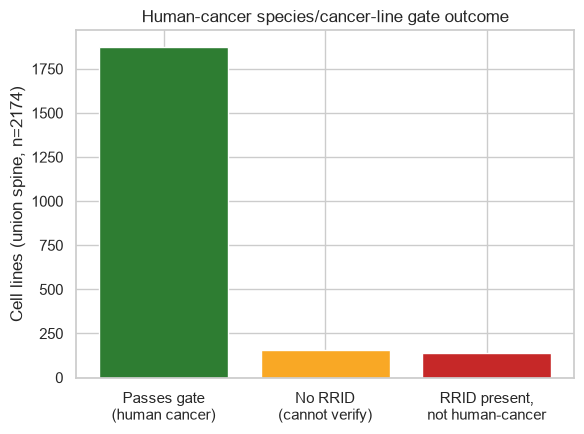

A sample of what falls outside the gate:
lineage_legacy
unknown              43
fibroblast           39
Soft Tissue          28
Esophagus/Stomach    20
Bone                 19
NaN                  13
blood                11
Skin                 11
Pancreas              9
CNS/Brain             8
Name: count, dtype: int64


In [6]:
fig, ax = plt.subplots(figsize=(6, 4.5))
gate_counts = pd.Series({
    'Passes gate\n(human cancer)': N,
    'No RRID\n(cannot verify)': len(no_rrid),
    'RRID present,\nnot human-cancer': len(rrid_not_human_cancer),
})
ax.bar(gate_counts.index, gate_counts.values, color=['#2E7D32', '#F9A825', '#C62828'])
ax.set_ylabel('Cell lines (union spine, n=%d)' % len(spine))
ax.set_title('Human-cancer species/cancer-line gate outcome')
plt.tight_layout()
plt.show()

print("A sample of what falls outside the gate:")
outside = spine[~spine['passes_species_cancer_gate']]
outside_lineage = outside['lineage_legacy'].combine_first(outside['lineage_modern'])
print(outside_lineage.value_counts(dropna=False).head(10))

### Why this EDA check matters

`N` is the single most important number in this notebook: it is the shared, gated denominator every
later per-layer, per-lineage, or per-pair coverage percentage in this pipeline must be measured
against. Rows failing the gate for "no RRID" are a **known-unknown** — they may well be legitimate
human cancer lines that simply cannot be verified through this bridge, not a claim that they are not
human cancer lines. Rows failing for "RRID present, not human-cancer" are lines DepMap catalogues
that Cellosaurus does not classify as a human cancer cell line (for example, engineered or
non-malignant lines) — correctly excluded from a *cancer* cell-line selector's candidate pool.

## 5. Reconcile lineage into one canonical column

`eda/single_layer/17_model_master_id_resolution_eda.ipynb` §3 already found the legacy `lineage`
(30 categories) and modern `OncotreeLineage` (34 categories) are **not** a clean 1:1 remap for every
category. This section reuses that finding and extends it across the full gated spine rather than
just the top-8-by-count categories notebook 17 displayed, then commits to one canonical column for
every notebook after this one to use.

In [7]:
overlap_lineage_pairs = gated_spine.loc[
    gated_spine['in_legacy'] & gated_spine['in_modern'], ['lineage_legacy', 'lineage_modern']
].dropna()

legacy_to_modern_spread = overlap_lineage_pairs.groupby('lineage_legacy')['lineage_modern'].nunique().sort_values(ascending=False)
modern_to_legacy_spread = overlap_lineage_pairs.groupby('lineage_modern')['lineage_legacy'].nunique().sort_values(ascending=False)

split_legacy = legacy_to_modern_spread[legacy_to_modern_spread > 1]
split_modern = modern_to_legacy_spread[modern_to_legacy_spread > 1]

print(f"Models present in both schemas (overlap)                 : {len(overlap_lineage_pairs)}")
print(f"Legacy lineage categories mapping to >1 modern category   : {len(split_legacy)} of {legacy_to_modern_spread.shape[0]}")
print(f"Modern lineage categories mapping to >1 legacy category   : {len(split_modern)} of {modern_to_legacy_spread.shape[0]}")
print()
print("Legacy categories that split across modern categories:")
print(split_legacy.to_string())

Models present in both schemas (overlap)                 : 1688
Legacy lineage categories mapping to >1 modern category   : 15 of 30
Modern lineage categories mapping to >1 legacy category   : 19 of 30

Legacy categories that split across modern categories:
lineage_legacy
soft_tissue                  6
gastric                      4
lung                         4
unknown                      4
colorectal                   3
bile_duct                    3
central_nervous_system       3
ovary                        2
thyroid                      2
skin                         2
plasma_cell                  2
peripheral_nervous_system    2
blood                        2
cervix                       2
uterus                       2


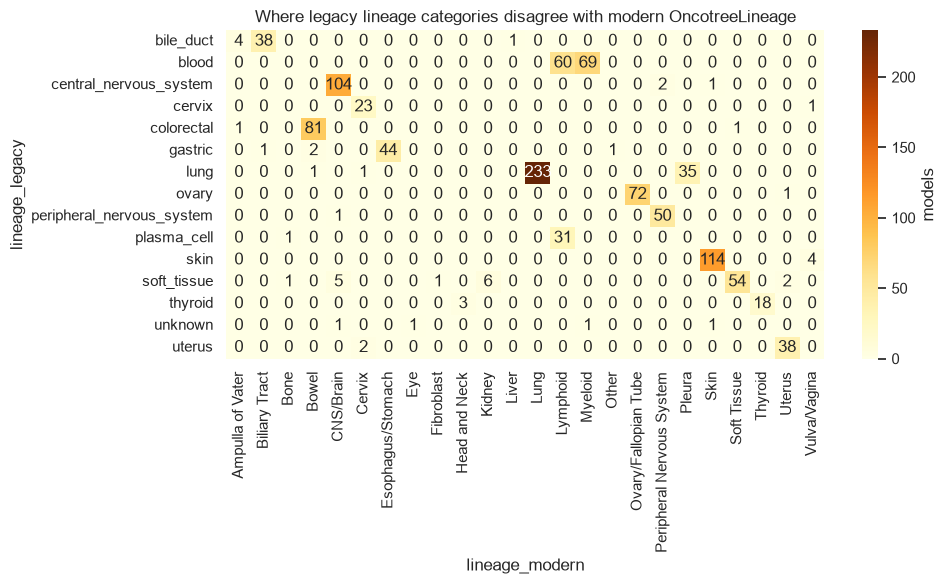

In [8]:
split_pairs = overlap_lineage_pairs[overlap_lineage_pairs['lineage_legacy'].isin(split_legacy.index)]
crosstab = pd.crosstab(split_pairs['lineage_legacy'], split_pairs['lineage_modern'])
fig, ax = plt.subplots(figsize=(10, max(3, 0.4 * len(crosstab))))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlOrBr', ax=ax, cbar_kws={'label': 'models'})
ax.set_title('Where legacy lineage categories disagree with modern OncotreeLineage')
plt.tight_layout()
plt.show()

### Why this EDA check matters

A legacy category that spreads across several modern categories (e.g. `lymphocyte` splitting into
distinct modern blood-cancer subtypes) means the two taxonomies genuinely disagree at the edges, not
just in naming convention — mixing them in one groupby would silently fragment or merge cancer
types. **Decision: the canonical lineage column coalesces modern `OncotreeLineage` first (the
current, more granular taxonomy, populated for 2,154 of the 2,174 union rows) and falls back to
legacy `lineage` only for the 20 models that exist solely in file 9.** This is a single, named
column every later notebook can group by without re-deciding which schema to trust.

In [9]:
gated_spine['lineage_canonical'] = gated_spine['lineage_modern'].combine_first(gated_spine['lineage_legacy'])
n_missing_lineage = gated_spine['lineage_canonical'].isna().sum()
print(f"Gated spine rows missing a canonical lineage: {n_missing_lineage} of {N}")
print(f"Canonical lineage categories: {gated_spine['lineage_canonical'].nunique()}")
print()
print("Top 15 lineages in the gated, canonical-lineage spine:")
print(gated_spine['lineage_canonical'].value_counts().head(15).to_string())

Gated spine rows missing a canonical lineage: 0 of 1874
Canonical lineage categories: 38

Top 15 lineages in the gated, canonical-lineage spine:
lineage_canonical
Lung                         252
Lymphoid                     221
Skin                         139
CNS/Brain                    116
Bowel                         96
Head and Neck                 91
Breast                        87
Esophagus/Stomach             84
Myeloid                       82
Bone                          77
Ovary/Fallopian Tube          75
Soft Tissue                   69
Kidney                        65
Peripheral Nervous System     61
Pancreas                      59


## 6. Join every measurement layer to the spine

Each layer below reuses the exact filter its own single-layer notebook established (cited inline),
producing a `has_<layer>` boolean on the gated spine. Coverage is reported as a **percentage of
`N`**, never of the layer's own row count — this is the key correction this notebook makes.

In [10]:
# RRID -> model_id lookup, restricted to the already-gated (human cancer) spine, used by every
# bridge-based layer below (HPA, GEO). A Cellosaurus accession is not always unique to one
# ModelID -- checked directly rather than assumed.
rrid_counts = gated_spine.dropna(subset=['RRID']).groupby('RRID')['model_id'].nunique()
shared_rrids = rrid_counts[rrid_counts > 1]
print(f"RRIDs shared by more than one ModelID in the gated spine: {len(shared_rrids)}")
if len(shared_rrids):
    dup_rows = gated_spine[gated_spine['RRID'].isin(shared_rrids.index)].sort_values('RRID')
    print(f"...affecting {len(dup_rows)} spine rows. Example:")
    print(dup_rows[['model_id', 'RRID', 'RRID_legacy', 'RRID_modern']].head(6).to_string(index=False))

# A one-to-many bridge: one Cellosaurus accession can legitimately resolve to more than one
# DepMap ModelID (most often a cell line re-profiled under a newer ModelID) -- both are the same
# physical cell line as far as an HPA/GEO measurement is concerned, so both should receive the
# bridged evidence rather than picking one arbitrarily.
rrid_to_models = gated_spine.dropna(subset=['RRID']).groupby('RRID')['model_id'].apply(set).to_dict()


def bridge_via_rrid(rrid_series: pd.Series) -> set:
    # Resolves a Series of Cellosaurus accessions to the set of gated spine model_ids they touch.
    out = set()
    for rrid in rrid_series.dropna():
        out |= rrid_to_models.get(rrid, set())
    return out


# CCLE_Name -> model_id lookup (legacy schema), used by the miRNA and metabolomics fallback joins.
ccle_to_model = (
    gated_spine.dropna(subset=['CCLE_Name'])
    .drop_duplicates('CCLE_Name')
    .set_index('CCLE_Name')['model_id']
)
print(f"\nRRID bridge covers {gated_spine['RRID'].notna().sum()} of {N} gated models")
print(f"CCLE_Name bridge covers {len(ccle_to_model)} of {N} gated models")

RRIDs shared by more than one ModelID in the gated spine: 6
...affecting 12 spine rows. Example:
  model_id      RRID RRID_legacy RRID_modern
ACH-000833 CVCL_0041   CVCL_0041   CVCL_0041
ACH-001189 CVCL_0041   CVCL_0041   CVCL_0041
ACH-001024 CVCL_1122   CVCL_1122   CVCL_1122
ACH-001041 CVCL_1122   CVCL_1122   CVCL_1122
ACH-001737 CVCL_1150   CVCL_1150         NaN
ACH-002222 CVCL_1150   CVCL_1150   CVCL_1150

RRID bridge covers 1874 of 1874 gated models
CCLE_Name bridge covers 1700 of 1874 gated models


### 6a. HPA RNA (file 1) — 3-hop bridge, per `eda/single_layer/01_hpa_rna_expression_eda.ipynb`

In [11]:
%%time
hpa_names = pd.read_csv(GENE_EXPRESSION / '1_4_hpa_rna_celline.tsv', sep='\t', usecols=['Cell line'])['Cell line'].unique()
df11 = pd.read_csv(NOMENCLATURE / '11_hpa_rna_celline_description.tsv', sep='\t', usecols=['Cell line', 'Cellosaurus ID'])
name_to_cvcl = df11.dropna(subset=['Cell line']).drop_duplicates('Cell line').set_index('Cell line')['Cellosaurus ID']

hpa_cvcl = pd.Series(hpa_names).map(name_to_cvcl).dropna()
hpa_models = bridge_via_rrid(hpa_cvcl)
print(f"HPA cell line names            : {len(hpa_names)}")
print(f"...reach a Cellosaurus ID      : {len(hpa_cvcl)}")
print(f"...reach the gated spine       : {len(hpa_models)}")

HPA cell line names            : 1206
...reach a Cellosaurus ID      : 1198
...reach the gated spine       : 1060
CPU times: total: 14.4 s
Wall time: 14.7 s


### 6b. DepMap RNA (file 2) — bridge via file 8, `Datatype == 'rna'`, per `eda/single_layer/02_depmap_rna_expression_eda.ipynb`

In [12]:
%%time
rna_profile_ids = set(pd.read_csv(GENE_EXPRESSION / '2_DepMap_OmicsExpressionAllGenesTPMLogp1Profile.csv', usecols=[0]).iloc[:, 0])
df8 = pd.read_csv(NOMENCLATURE / '8_DepMap_OmicsProfiles.csv', usecols=['ProfileID', 'ModelID', 'Datatype'])
df8_rna = df8[df8['Datatype'] == 'rna']
rna_models = set(df8_rna.loc[df8_rna['ProfileID'].isin(rna_profile_ids), 'ModelID'].dropna())
print(f"DepMap RNA profiles (file 2)   : {len(rna_profile_ids)}")
print(f"...resolve to a ModelID        : {rna_models.__len__()}")

DepMap RNA profiles (file 2)   : 1495
...resolve to a ModelID        : 1479
CPU times: total: 6.52 s
Wall time: 6.58 s


### 6c. GEO RNA (file 3) — 3-hop bridge, per `eda/single_layer/03_geo_rna_expression_eda.ipynb`

In [13]:
%%time
geo_header = pd.read_csv(GENE_EXPRESSION / '3_GEOexpression.txt', sep='\t', nrows=0).columns
gsm_cols = [c for c in geo_header if c.startswith('GSM')]
df10 = pd.read_csv(NOMENCLATURE / '10_GEOInfo.txt', sep='\t', usecols=['Geo_accession', 'Cellosaurus_ID'])
gsm_to_cvcl = df10.dropna(subset=['Cellosaurus_ID']).drop_duplicates('Geo_accession').set_index('Geo_accession')['Cellosaurus_ID']

geo_cvcl = pd.Series(gsm_cols).map(gsm_to_cvcl).dropna()
geo_models = bridge_via_rrid(geo_cvcl)
print(f"GEO sample columns (file 3)    : {len(gsm_cols)}")
print(f"...reach a Cellosaurus ID      : {len(geo_cvcl)}")
print(f"...reach the gated spine       : {len(geo_models)}")

GEO sample columns (file 3)    : 3267
...reach a Cellosaurus ID      : 3159
...reach the gated spine       : 592
CPU times: total: 422 ms
Wall time: 428 ms


### 6d. Proteomics (file 4) — direct `ModelID` key, per `eda/single_layer/04_proteomics_ms_eda.ipynb`

In [14]:
prot_models = set(pd.read_csv(GENE_EXPRESSION / '4_Harmonized_MS_CCLE_Gygi_subsetted.csv', usecols=[0]).iloc[:, 0])
print(f"Proteomics models (file 4): {len(prot_models)}")

Proteomics models (file 4): 375


### 6e. Fusions (file 5) — `IsDefaultEntryForModel == 'Yes'`, per `eda/single_layer/05_gene_fusions_eda.ipynb`

In [15]:
df5 = pd.read_csv(GENE_PROPERTIES / '5_OmicsFusionFilteredSupplementary.csv', usecols=['ModelID', 'IsDefaultEntryForModel'])
fusion_models = set(df5.loc[df5['IsDefaultEntryForModel'] == 'Yes', 'ModelID'].dropna())
print(f"Fusion-assayed models (file 5, default entry only): {len(fusion_models)}")

Fusion-assayed models (file 5, default entry only): 1699


### 6f. Mutations (file 6) — bridge via file 8, `Datatype in {wes, wgs}`, per `eda/single_layer/06_somatic_mutations_eda.ipynb`

In [16]:
%%time
mut_profiles = set(pd.read_csv(GENE_PROPERTIES / '6_OmicsSomaticMutationsProfile.csv', usecols=['ProfileID'], low_memory=False)['ProfileID'].dropna())
df8_dna = df8[df8['Datatype'].isin(['wes', 'wgs'])]
mut_models = set(df8_dna.loc[df8_dna['ProfileID'].isin(mut_profiles), 'ModelID'].dropna())
print(f"Mutation-call profiles (file 6): {len(mut_profiles)}")
print(f"...resolve to a ModelID        : {len(mut_models)}")

Mutation-call profiles (file 6): 2828
...resolve to a ModelID        : 1744
CPU times: total: 10.8 s
Wall time: 11.4 s


### 6g. Metabolomics (file 12) — `DepMap_ID` direct, `CCLE_ID` fallback, per `eda/single_layer/12_metabolomics_eda.ipynb`

In [17]:
df12 = pd.read_csv(NON_GENE_EXPRESSION / '12_CCLE_metabolomics_20190502.csv', usecols=['DepMap_ID', 'CCLE_ID'])
metab_direct = set(df12['DepMap_ID'].dropna())
missing_depmapid = df12[df12['DepMap_ID'].isna()]
metab_fallback = set(missing_depmapid['CCLE_ID'].map(ccle_to_model).dropna())
metab_models = metab_direct | metab_fallback
print(f"Metabolomics rows with DepMap_ID directly : {len(metab_direct)}")
print(f"Rows needing the CCLE_ID fallback          : {len(missing_depmapid)} (recovered {len(metab_fallback)})")
print(f"Metabolomics models total (file 12)        : {len(metab_models)}")

Metabolomics rows with DepMap_ID directly : 927
Rows needing the CCLE_ID fallback          : 1 (recovered 1)
Metabolomics models total (file 12)        : 928


### 6h. miRNA (file 13) — GCT format, `CCLE_ID`-keyed, per `eda/single_layer/13_mirna_eda.ipynb`

Notebook 13's fix applies here too: the file's raw column headers *are* `CCLE_ID`s (not the
`Description`-mapped miRNA names — that mapping only matters for the row/probe axis, which this
notebook does not need since it only asks "which cell lines are present," not "which miRNAs").

In [18]:
mirna_header = pd.read_csv(NON_GENE_EXPRESSION / '13_CCLE_miRNA_20181103.gct', sep='\t', skiprows=2, index_col=0, nrows=0).columns
mirna_ccle_ids = [c for c in mirna_header if c != 'Description']
mirna_models = set(pd.Series(mirna_ccle_ids).map(ccle_to_model).dropna())
print(f"miRNA CCLE_ID columns (file 13)      : {len(mirna_ccle_ids)}")
print(f"...resolve to the gated spine        : {len(mirna_models)}")

miRNA CCLE_ID columns (file 13)      : 954
...resolve to the gated spine        : 909


### 6i. Genome signatures (file 14) — `IsDefaultEntryForModel == 'Yes'`, per `eda/single_layer/14_genomic_signatures_eda.ipynb`

In [19]:
df14 = pd.read_csv(NON_GENE_EXPRESSION / '14_OmicsGlobalSignatures.csv', usecols=['ModelID', 'IsDefaultEntryForModel'])
sig_models = set(df14.loc[df14['IsDefaultEntryForModel'] == 'Yes', 'ModelID'].dropna())
print(f"Genome-signature models (file 14, default entry only): {len(sig_models)}")

Genome-signature models (file 14, default entry only): 1955


### 6j. CRISPR dependency (file 15, augmented) — direct `ModelID` key, per `eda/single_layer/15_crispr_gene_effect_eda.ipynb`

In [20]:
crispr_models = set(pd.read_csv(AUGMENTED / 'gene_properties' / '15_CRISPRGeneEffect.csv', usecols=[0]).iloc[:, 0])
print(f"CRISPR-screened models (file 15): {len(crispr_models)}")

CRISPR-screened models (file 15): 1208


### 6k. Copy number, WGS (file 16, augmented) — `IsDefaultEntryForModel == 'Yes'`, per `eda/single_layer/16_absolute_copy_number_eda.ipynb`

In [21]:
df16 = pd.read_csv(AUGMENTED / 'gene_properties' / '16_OmicsCNGeneWGS.csv', usecols=['ModelID', 'IsDefaultEntryForModel'])
cn_models = set(df16.loc[df16['IsDefaultEntryForModel'] == 'Yes', 'ModelID'].dropna())
print(f"WGS copy-number models (file 16, default entry only): {len(cn_models)}")

WGS copy-number models (file 16, default entry only): 1118


### 6l. Coverage table — every layer against the same denominator, `N`

In [22]:
layer_model_sets = {
    'hpa_rna': hpa_models,
    'depmap_rna': rna_models,
    'geo_rna': geo_models,
    'proteomics': prot_models,
    'fusions': fusion_models,
    'mutations': mut_models,
    'metabolomics': metab_models,
    'mirna': mirna_models,
    'genome_signatures': sig_models,
    'crispr': crispr_models,
    'copy_number': cn_models,
}

for name, models in layer_model_sets.items():
    gated_spine[f'has_{name}'] = gated_spine['model_id'].isin(models)

coverage_rows = []
for name in layer_model_sets:
    n_covered = int(gated_spine[f'has_{name}'].sum())
    coverage_rows.append({
        'layer': name,
        'models_covered_of_gated_spine': n_covered,
        'coverage_pct_of_N': round(100 * n_covered / N, 1),
        'raw_layer_size': len(layer_model_sets[name]),
    })
layer_coverage = pd.DataFrame(coverage_rows).sort_values('models_covered_of_gated_spine', ascending=False).reset_index(drop=True)
layer_coverage

,layer,models_covered_of_gated_spine,coverage_pct_of_N,raw_layer_size
0,genome_signatures,1765,94.2,1955
1,mutations,1638,87.4,1744
2,fusions,1517,80.9,1699
3,depmap_rna,1383,73.8,1479
4,crispr,1158,61.8,1208
5,hpa_rna,1060,56.6,1060
6,copy_number,1052,56.1,1118
7,mirna,909,48.5,909
8,metabolomics,908,48.5,928
9,geo_rna,592,31.6,592


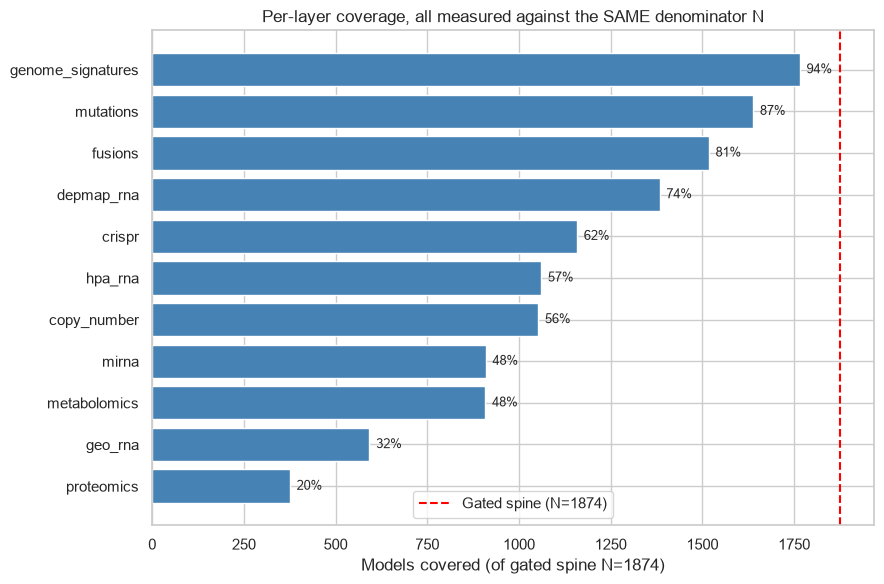

In [23]:
fig, ax = plt.subplots(figsize=(9, 6))
plot_df = layer_coverage.sort_values('models_covered_of_gated_spine')
bars = ax.barh(plot_df['layer'], plot_df['models_covered_of_gated_spine'], color='steelblue')
ax.axvline(N, color='red', linestyle='--', label=f'Gated spine (N={N})')
for bar, pct in zip(bars, plot_df['coverage_pct_of_N']):
    ax.text(bar.get_width() + N * 0.01, bar.get_y() + bar.get_height() / 2, f'{pct:.0f}%', va='center', fontsize=9)
ax.set_xlabel(f'Models covered (of gated spine N={N})')
ax.set_title('Per-layer coverage, all measured against the SAME denominator N')
ax.legend()
plt.tight_layout()
plt.show()

### Why this EDA check matters

This is the direct correction the whole notebook exists to make: every one of these percentages now
means "fraction of the same 2,xxx human cancer cell lines," not "fraction of whatever population
that one file happened to define." A researcher who reads "CRISPR: 61%" here can compare it
honestly against "fusions: 79%" for the first time — those two numbers were never comparable when
each single-layer notebook reported them against its own file's row count.

## 7. Duplicate/multiplicity audit before default-profile resolution

RNA (file 2) and mutations (file 6) are both `ProfileID`-keyed, and a model can carry more than one
sequencing run of the same type (`eda/single_layer/08_depmap_omics_profiles_eda.ipynb` §2). Unlike
fusions/signatures/copy-number, which ship an explicit `IsDefaultEntryForModel` flag, RNA and
mutations have **no such flag** — this section checks how much multiplicity survives the
`Datatype` filter alone, and whether a `has_<layer>` presence boolean is enough or a true
default-profile rule is still owed to `preprocessing/`.

In [24]:
rna_profiles_per_model = df8_rna.loc[df8_rna['ProfileID'].isin(rna_profile_ids)].groupby('ModelID').size()
mut_profiles_per_model = df8_dna.loc[df8_dna['ProfileID'].isin(mut_profiles)].groupby('ModelID').size()

print("RNA (file 2, via file 8 Datatype=='rna'):")
print(f"  models with exactly 1 profile : {(rna_profiles_per_model == 1).sum()}")
print(f"  models with >1 profile        : {(rna_profiles_per_model > 1).sum()} of {len(rna_profiles_per_model)}")
print()
print("Mutations (file 6, via file 8 Datatype in {wes, wgs}):")
print(f"  models with exactly 1 profile : {(mut_profiles_per_model == 1).sum()}")
print(f"  models with >1 profile        : {(mut_profiles_per_model > 1).sum()} of {len(mut_profiles_per_model)}")

RNA (file 2, via file 8 Datatype=='rna'):
  models with exactly 1 profile : 1463
  models with >1 profile        : 16 of 1479

Mutations (file 6, via file 8 Datatype in {wes, wgs}):
  models with exactly 1 profile : 1205
  models with >1 profile        : 539 of 1744


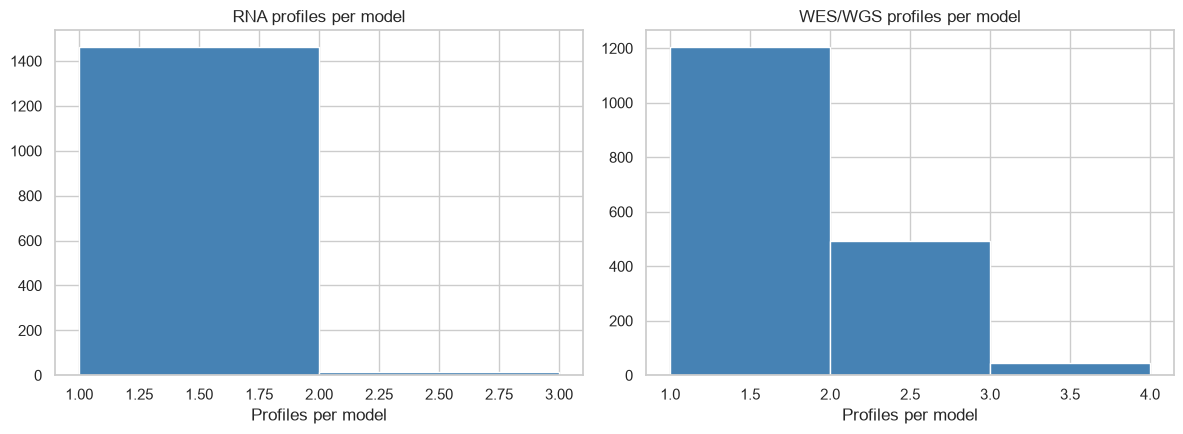

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, series, title in zip(
    axes, [rna_profiles_per_model, mut_profiles_per_model], ['RNA profiles per model', 'WES/WGS profiles per model']
):
    ax.hist(series, bins=range(1, int(series.max()) + 2), color='steelblue', edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Profiles per model')
plt.tight_layout()
plt.show()

### Why this EDA check matters

The `has_<layer>` boolean this notebook uses is a presence flag, unaffected by multiplicity — a
model with two RNA profiles or a model with one both show `has_depmap_rna == True`. That is
sufficient for the coverage percentages in §6, but it is **not** sufficient for any per-model
*value* (an actual expression level, a mutation call): the multiplicity confirmed here (RNA is
close to 1:1 per `eda/single_layer/02_depmap_rna_expression_eda.ipynb` §6's 1.06 ratio; mutations
carry real WES/WGS overlap) means **`preprocessing/` still owes a default-profile selection rule
before any per-model score can be computed from either layer** — this audit does not resolve that,
it confirms the resolution is still needed.

## 8. Pairwise layer-overlap matrix

For every pair of the eleven layers: how many gated-spine models carry **both**, and — since "does
A imply B" is not symmetric — what fraction of A's models also have B, shown as a directional
percentage (read row -> column).

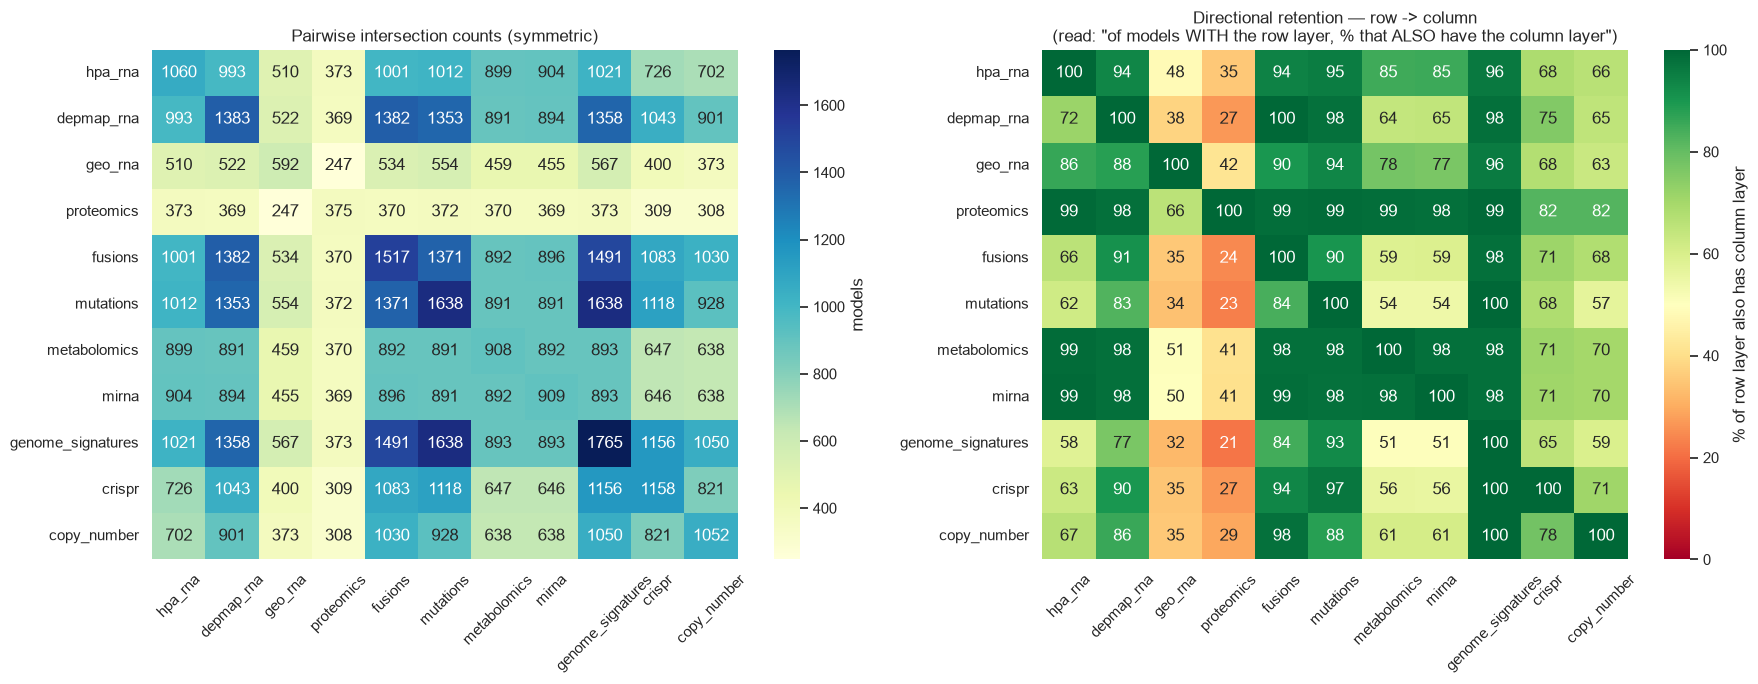

In [26]:
layer_names = list(layer_model_sets.keys())
bool_cols = [f'has_{n}' for n in layer_names]
bool_df = gated_spine[['model_id'] + bool_cols].set_index('model_id')
bool_df.columns = layer_names

layer_counts = bool_df.sum()
intersection = pd.DataFrame(index=layer_names, columns=layer_names, dtype=int)
row_retention = pd.DataFrame(index=layer_names, columns=layer_names, dtype=float)

for a in layer_names:
    for b in layer_names:
        inter = int((bool_df[a] & bool_df[b]).sum())
        intersection.loc[a, b] = inter
        row_retention.loc[a, b] = 100 * inter / layer_counts[a] if layer_counts[a] else np.nan

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(intersection.astype(int), annot=True, fmt='d', cmap='YlGnBu', ax=axes[0], cbar_kws={'label': 'models'})
axes[0].set_title('Pairwise intersection counts (symmetric)')
sns.heatmap(row_retention.astype(float), annot=True, fmt='.0f', cmap='RdYlGn', vmin=0, vmax=100, ax=axes[1],
            cbar_kws={'label': '% of row layer also has column layer'})
axes[1].set_title('Directional retention — row -> column\n(read: "of models WITH the row layer, % that ALSO have the column layer")')
for ax in axes:
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

### Why this EDA check matters

The symmetric intersection count answers "how big is the usable cohort for A-and-B together" — the
real denominator for any two-layer comparison (e.g. RNA-protein concordance in a later notebook).
The directional retention answers a different question — "if a line has A, how likely is it to also
have B" — which is what tells a researcher whether a rarer layer (proteomics, CRISPR) is mostly
*nested inside* a broader one (RNA, mutations) or genuinely measures a different subset of lines.
**Descriptive only**: a high retention percentage says two assays tend to run on the same lines, not
that one assay's presence causes the other's.

## 9. Multi-layer missingness pattern

Which combinations of layers tend to be jointly present or absent together — a coarse check for
whether missingness is scattered independently across layers or clusters (e.g. lines with rich
sequencing coverage but no functional screens, versus lines missing almost everything).

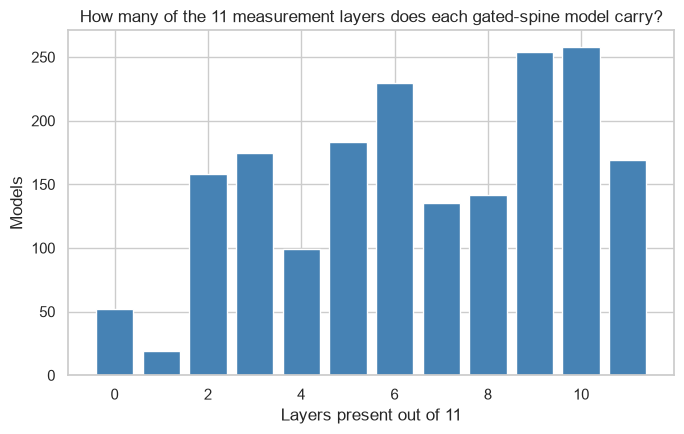

Median layers present per model: 7
Models with 0 of 11 layers      : 52
Models with all 11 layers       : 169


In [27]:
gated_spine['n_layers_present'] = bool_df.sum(axis=1).values

fig, ax = plt.subplots(figsize=(7, 4.5))
counts = gated_spine['n_layers_present'].value_counts().sort_index()
ax.bar(counts.index, counts.values, color='steelblue')
ax.set_xlabel(f'Layers present out of {len(layer_names)}')
ax.set_ylabel('Models')
ax.set_title('How many of the 11 measurement layers does each gated-spine model carry?')
plt.tight_layout()
plt.show()
print(f"Median layers present per model: {gated_spine['n_layers_present'].median():.0f}")
print(f"Models with 0 of 11 layers      : {(gated_spine['n_layers_present'] == 0).sum()}")
print(f"Models with all 11 layers       : {(gated_spine['n_layers_present'] == len(layer_names)).sum()}")

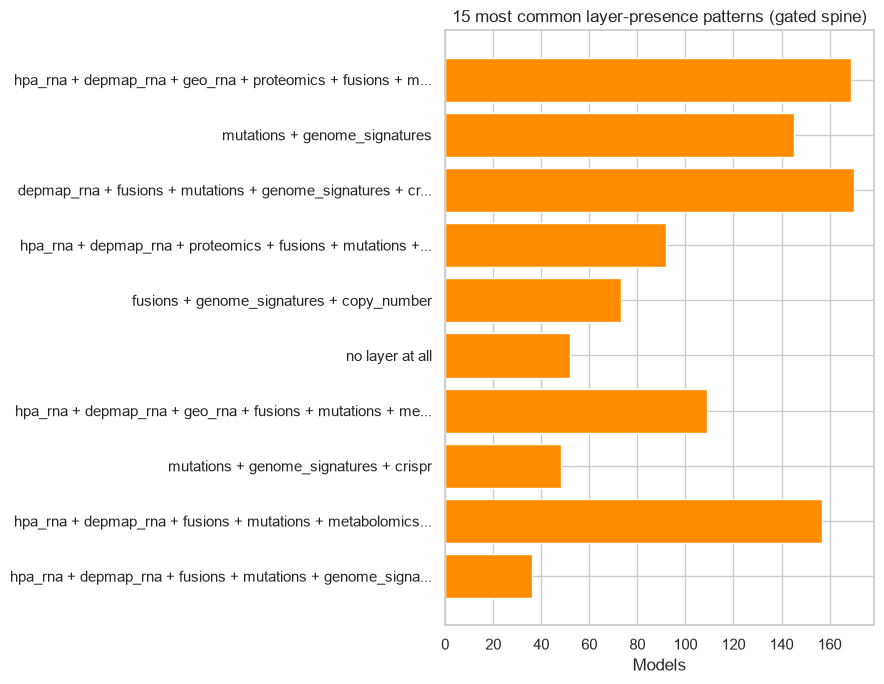

pattern
depmap_rna + fusions + mutations + genome_signatures + crispr + copy_number                                                            170
hpa_rna + depmap_rna + geo_rna + proteomics + fusions + mutations + metabolomics + mirna + genome_signatures + crispr + copy_number    169
hpa_rna + depmap_rna + fusions + mutations + metabolomics + mirna + genome_signatures + crispr + copy_number                           157
mutations + genome_signatures                                                                                                          145
depmap_rna + fusions + mutations + genome_signatures + crispr                                                                          122
hpa_rna + depmap_rna + geo_rna + fusions + mutations + metabolomics + mirna + genome_signatures + crispr + copy_number                 109
hpa_rna + depmap_rna + proteomics + fusions + mutations + metabolomics + mirna + genome_signatures + crispr + copy_number               92
fusions + genome_si

In [28]:
def pattern_str(row):
    present = [n for n in layer_names if row[n]]
    return ' + '.join(present) if present else 'no layer at all'


bool_df_pattern = bool_df.copy()
bool_df_pattern['pattern'] = bool_df_pattern.apply(pattern_str, axis=1)
top_patterns = bool_df_pattern['pattern'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh([p if len(p) < 60 else p[:57] + '...' for p in top_patterns.index[::-1]], top_patterns.values[::-1], color='darkorange')
ax.set_xlabel('Models')
ax.set_title('15 most common layer-presence patterns (gated spine)')
plt.tight_layout()
plt.show()
top_patterns

In [29]:
# Co-missingness check: is proteomics absence linked with metabolomics absence, or largely
# independent? A crosstab, not a correlation coefficient, to keep the descriptive claim modest.
co_missing = pd.crosstab(
    gated_spine['has_proteomics'].map({True: 'has proteomics', False: 'no proteomics'}),
    gated_spine['has_metabolomics'].map({True: 'has metabolomics', False: 'no metabolomics'}),
)
print("Proteomics x metabolomics presence (gated spine):")
print(co_missing)
print()

# Same check for the two "expensive assay" layers -- CRISPR and copy number -- both WGS/functional
# screens that require extra wet-lab work beyond standard sequencing.
co_missing_expensive = pd.crosstab(
    gated_spine['has_crispr'].map({True: 'has CRISPR', False: 'no CRISPR'}),
    gated_spine['has_copy_number'].map({True: 'has copy number', False: 'no copy number'}),
)
print("CRISPR x copy-number presence (gated spine):")
print(co_missing_expensive)

Proteomics x metabolomics presence (gated spine):
has_metabolomics  has metabolomics  no metabolomics
has_proteomics                                     
has proteomics                 370                5
no proteomics                  538              961

CRISPR x copy-number presence (gated spine):
has_copy_number  has copy number  no copy number
has_crispr                                      
has CRISPR                   821             337
no CRISPR                    231             485


### Why this EDA check matters

A model missing several layers *together* is a structurally different evidence situation than a
model missing one layer at random — the former should be flagged as low-evidence overall (per
`docs/PROJECT_ARCHITECTURE.md` §7's "insufficient evidence, not ranked last" rule), while the latter
just abstains on that one layer's contribution. The crosstabs above are **descriptive counts, not a
correlation coefficient or a causal claim** — a shared pattern (e.g. CRISPR and copy-number tending
to co-occur, since both come from more resource-intensive DepMap experimental programs) is a
plausible operational explanation, not something this notebook tests statistically or attributes a
cause to.

## 10. Biological examples, candidate features, limitations, decisions carried forward

### Biological examples — a coverage fingerprint for two well-known lines

In [30]:
# A deliberately contrasting pair -- the richest-evidence and the sparsest-evidence (but still
# gated-eligible) model -- illustrates what "evidence-weighted mean over present layers" actually
# averages over in practice, rather than picking two arbitrary IDs that might coincidentally match.
sparse_but_present = gated_spine[gated_spine['n_layers_present'] > 0].sort_values('n_layers_present')
richest_model = gated_spine.sort_values('n_layers_present', ascending=False)['model_id'].iloc[0]
sparsest_model = sparse_but_present['model_id'].iloc[0]
present_examples = [richest_model, sparsest_model]

example_cols = ['model_id', 'lineage_canonical', 'n_layers_present'] + [f'has_{n}' for n in layer_names]
gated_spine[gated_spine['model_id'].isin(present_examples)][example_cols].T

,906,1079
model_id,ACH-000957,ACH-001230
lineage_canonical,Bowel,Myeloid
n_layers_present,11,1
has_hpa_rna,True,False
has_depmap_rna,True,False
has_geo_rna,True,True
has_proteomics,True,False
has_fusions,True,False
has_mutations,True,False
has_metabolomics,True,False


These two rows are a concrete illustration of what "evidence-weighted mean over present layers"
(`docs/PROJECT_ARCHITECTURE.md` §5b) actually averages over in practice: one line with almost every
layer measured (a strong-evidence candidate) against one with very few (a candidate that, per §7,
would surface with a visibly lower coverage tier and should never be silently treated as having
"no dependency" or "no fusion" — only "not assayed"). The 52 models with **zero** layers (§9) are
not shown here since they belong under §7's "insufficient evidence — not ranked" rule entirely,
never compared gene-by-gene against a well-covered line.

### Candidate feature ideas

- **`n_layers_present`** (§9) as a direct evidence-richness feature — a coarse but honest proxy for
  how much a result card can say about a given line, independent of any per-gene score.
- **`has_<layer>` booleans** (§6) as the direct input to §7's three-state (`measured` /
  `measured_absent` / `not_assayed`) framework `preprocessing/` will need to build per gene per
  layer, not just per model per layer as computed here.
- **`lineage_canonical`** (§5) as the single stratification column for every later lineage-adjusted
  analysis (notebook 02 and beyond) — one column, one taxonomy, no re-deciding which schema to use.
- **Layer-presence pattern** (§9) as a categorical cohort label — useful for grouping models into
  "well-characterised" versus "sparse-evidence" strata before any correlation work, per the minimum
  group-size caution in `docs/PROJECT_ARCHITECTURE.md` §4.

### Limitations

1. **The species/cancer gate is bridge-limited, not identity-limited** (§4): a model with no RRID at
   all is excluded from `N` even though it may be a genuine human cancer line — this is a
   conservative choice (favouring certainty over inclusiveness) that a later notebook could revisit
   if the excluded set turns out to be large and lineage-biased.
2. **RNA and mutation multiplicity is only partially resolved** (§7): the `has_<layer>` presence
   flags used throughout §6, §8 and §9 are unaffected by a model carrying more than one profile, but
   any per-model *value* still needs a default-profile rule this notebook does not build (that
   belongs in `preprocessing/`, per `eda/_.md`'s "no runtime stage may read from this folder" rule).
3. **3-hop bridges (HPA, GEO) inherit compounding loss at every hop** — the HPA and GEO coverage
   numbers in §6 are a ceiling set by identity resolution as much as by the assay itself, exactly as
   `eda/single_layer/01` and `03` found in isolation.
4. **Metabolomics (2019-05-02) and miRNA (2018-11-03) predate the modern schema** — their coverage
   numbers here are correct against `N`, but the release-mismatch caution in
   `docs/PROJECT_ARCHITECTURE.md` §2 still applies to any claim that compares them against a
   modern-schema-only layer.
5. **The co-missingness crosstabs in §9 are descriptive, not causal or statistically tested** — no
   correlation coefficient, significance test, or mechanism claim is made from a shared presence
   pattern, per root `_.md` §3.
6. This notebook reports coverage; it does not decide the `docs/PROJECT_ARCHITECTURE.md` §6
   admission-gate verdict for any layer — that decision belongs in `docs/plan/METHOD_DECISION.md`,
   using these numbers as A2 (coverage) evidence.
7. **A handful of Cellosaurus accessions resolve to more than one `ModelID`** (§6, discovered while
   building the RRID bridge — not assumed in advance): a small number of physical cell lines were
   re-profiled by DepMap under a newer `ModelID` without retiring the older one from the catalogue.
   Both are kept in the spine and both receive bridged HPA/GEO evidence (`bridge_via_rrid`), which
   is the biologically correct call — they are the same cell line — but it does mean `N` counts two
   spine rows for what is, physically, one cell line in these few cases. This was not anticipated
   before running the code and is exactly the kind of identity edge case root `_.md` §6 asks this
   phase to surface, not assume away.

### Decisions carried into the next notebooks

1. **Gated spine size `N`** is fixed at the value printed in §4 above — every later coverage,
   lineage-bias, or route-cohort number in `eda/cross_layer/` must cite this same `N`, not
   recompute its own.
2. **Canonical lineage column: `lineage_canonical`** (§5) — modern `OncotreeLineage` first, legacy
   `lineage` fallback for the 20 legacy-only models. Group by this column, not by `lineage` or
   `OncotreeLineage` directly, in any later notebook.
3. **Per-layer coverage (`layer_coverage`, §6l)** is the number notebook 02 (lineage coverage bias)
   and notebook 03 (RNA cross-source concordance) must cite as their starting denominators, printed
   again below for direct citation.
4. **RNA and mutation default-profile resolution remains an open item for `preprocessing/`** (§7) —
   not resolved by a presence flag alone.
5. **Pairwise overlap and multi-layer missingness (§8, §9)** define which two-layer or multi-layer
   cohorts are large enough to be worth analysing next — small pairwise intersections should not be
   treated as adequate for a lineage-stratified comparison without checking the minimum group-size
   rule in `docs/PROJECT_ARCHITECTURE.md` §4 first.

In [31]:
print(f"FINAL GATED SPINE SIZE: N = {N}")
print(f"Canonical lineage column: 'lineage_canonical' ({gated_spine['lineage_canonical'].nunique()} categories)")
print()
print("Per-layer coverage, citable by later notebooks:")
print(layer_coverage.to_string(index=False))

FINAL GATED SPINE SIZE: N = 1874
Canonical lineage column: 'lineage_canonical' (38 categories)

Per-layer coverage, citable by later notebooks:
            layer  models_covered_of_gated_spine  coverage_pct_of_N  raw_layer_size
genome_signatures                           1765               94.2            1955
        mutations                           1638               87.4            1744
          fusions                           1517               80.9            1699
       depmap_rna                           1383               73.8            1479
           crispr                           1158               61.8            1208
          hpa_rna                           1060               56.6            1060
      copy_number                           1052               56.1            1118
            mirna                            909               48.5             909
     metabolomics                            908               48.5             928
          geo_rn